In [2]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset (ajusta el nombre del archivo si se llama diferente en tu carpeta)
# Cambiamos read_csv por read_excel y ajustamos la extensión a .xlsx
df = pd.read_excel('WA_Fn-UseC_-Telco-Customer-Churn.xlsx')
#df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') 

# 2. Corregir la columna TotalCharges (los espacios en blanco de clientes nuevos)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 3. Mostrar las primeras 5 filas y la información general del DataFrame
print("--- Primeras Filas ---")
display(df.head())

print("\n--- Información del Dataset ---")
df.info()

--- Primeras Filas ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  70

C:\Users\CarlosGO\AppData\Local\Temp\ipykernel_21232\3063725906.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')
C:\Users\CarlosGO\AppData\Local\Temp\ipykernel_21232\3063725906.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')


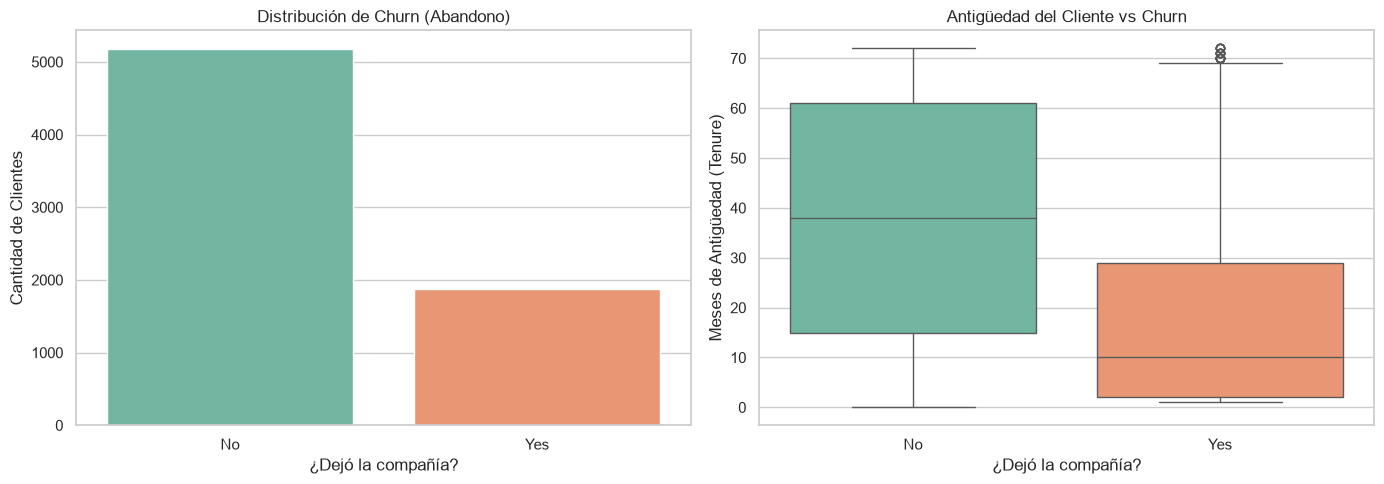

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Gráfico 1: Distribución del Churn (¿Cuántos se van vs. cuántos se quedan?)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribución de Churn (Abandono)')
plt.xlabel('¿Dejó la compañía?')
plt.ylabel('Cantidad de Clientes')

# Gráfico 2: Relación entre Antigüedad (tenure) y Churn
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')
plt.title('Antigüedad del Cliente vs Churn')
plt.xlabel('¿Dejó la compañía?')
plt.ylabel('Meses de Antigüedad (Tenure)')

plt.tight_layout()
plt.show()

In [4]:
# Lista de columnas de servicios para calcular la "Frecuencia" (Engagement)
servicios = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
             'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Contamos cuántos servicios tiene contratados (asumiendo que 'No' o 'No internet service' es 0)
df['Frecuencia_Servicios'] = df[servicios].apply(lambda row: sum(row.astype(str).str.lower().str.contains('yes')), axis=1)

# Creamos un nuevo DataFrame solo con los clientes ACTIVOS (Churn == 'No') para la segmentación RFM
df_activos = df[df['Churn'] == 'No'].copy()

# Seleccionamos nuestras variables para el análisis RFM
# Recencia: tenure (a mayor tenure, más leal/reciente en actividad continua)
# Frecuencia: Frecuencia_Servicios (número de servicios contratados)
# Monetario: MonthlyCharges (gasto mensual actual)
rfm_df = df_activos[['tenure', 'Frecuencia_Servicios', 'MonthlyCharges']].copy()

print("--- Estadísticas de nuestras variables de segmentación ---")
display(rfm_df.describe())

--- Estadísticas de nuestras variables de segmentación ---


,tenure,Frecuencia_Servicios,MonthlyCharges
count,5174.000000,5174.000000,5174.000000
mean,37.569965,3.446270,61.265124
std,24.113777,2.156391,31.092648
min,0.000000,0.000000,18.250000
25%,15.000000,1.000000,25.100000
50%,38.000000,3.000000,64.425000
75%,61.000000,5.000000,88.400000
max,72.000000,8.000000,118.750000


In [6]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 51.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   ----------------------

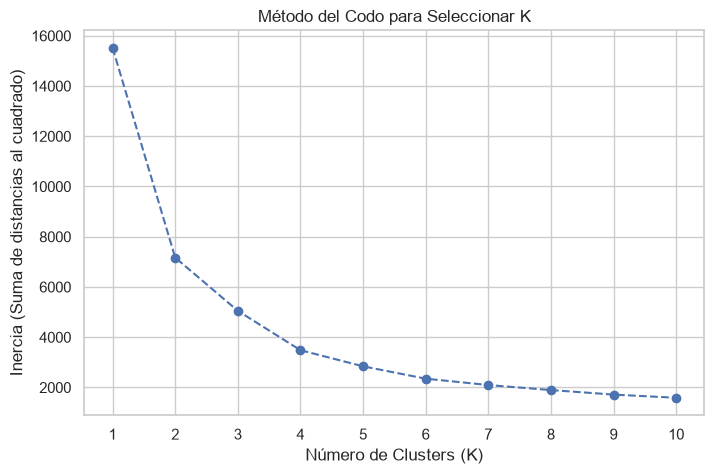

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Escalamos los datos RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)

# 2. Calculamos la inercia para diferentes cantidades de clusters (1 al 10)
inercia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inercia.append(kmeans.inertia_)

# 3. Dibujamos el Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para Seleccionar K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [8]:
# 1. Definimos y entrenamos el modelo K-Means con K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_activos['Cluster'] = kmeans_final.fit_transform(rfm_scaled).argmin(axis=1) 
# Usamos argmin o directamente labels_ para asignar el grupo
df_activos['Cluster'] = kmeans_final.labels_

# 2. Calculamos los promedios de cada métrica por Cluster para poder analizarlos
perfil_clusters = df_activos.groupby('Cluster')[['tenure', 'Frecuencia_Servicios', 'MonthlyCharges']].mean()

# Añadimos también cuántos clientes cayeron en cada grupo
perfil_clusters['Cantidad_Clientes'] = df_activos['Cluster'].value_counts()

print("--- Perfil Promedio de los Segmentos de Clientes ---")
display(perfil_clusters)

--- Perfil Promedio de los Segmentos de Clientes ---


,tenure,Frecuencia_Servicios,MonthlyCharges,Cantidad_Clientes
Cluster,,,,
0,31.233440,1.326923,25.795326,1872
1,59.030254,5.715829,89.265451,1851
2,18.368711,3.285320,71.307064,1451


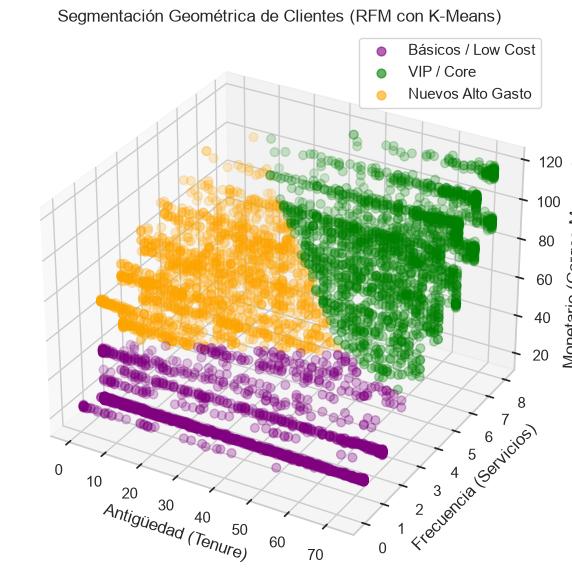

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Colores para nuestros clusters
colores = {0: 'purple', 1: 'green', 2: 'orange'}
labels_negocio = {0: 'Básicos / Low Cost', 1: 'VIP / Core', 2: 'Nuevos Alto Gasto'}

for cluster_id in [0, 1, 2]:
    subset = df_activos[df_activos['Cluster'] == cluster_id]
    ax.scatter(subset['tenure'], subset['Frecuencia_Servicios'], subset['MonthlyCharges'], 
               c=colores[cluster_id], label=labels_negocio[cluster_id], s=40, alpha=0.6)

ax.set_title('Segmentación Geométrica de Clientes (RFM con K-Means)')
ax.set_xlabel('Antigüedad (Tenure)')
ax.set_ylabel('Frecuencia (Servicios)')
ax.set_zlabel('Monetario (Cargos Mensuales)')
ax.legend()

plt.show()

In [10]:
# 1. Creamos una copia del DataFrame original para no alterar los datos limpios anteriores
df_modelo = df.copy()

# 2. Eliminamos columnas que no aportan valor predictivo directo (IDs)
if 'customerID' in df_modelo.columns:
    df_modelo = df_modelo.drop(columns=['customerID'])

# 3. Convertimos la variable objetivo Churn a numérica (1 si se va, 0 si se queda)
df_modelo['Churn'] = df_modelo['Churn'].map({'Yes': 1, 'No': 0})

# 4. Tratamos los nulos que dejamos en TotalCharges rellenándolos con la mediana (para que el modelo no falle)
df_modelo['TotalCharges'] = df_modelo['TotalCharges'].fillna(df_modelo['TotalCharges'].median())

# 5. Convertimos todas las variables categóricas en dummies (0 y 1)
df_procesado = pd.get_dummies(df_modelo, drop_first=True)

print(df_procesado.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   Frecuencia_Servicios                   7043 non-null   int64  
 6   gender_Male                            7043 non-null   bool   
 7   Partner_Yes                            7043 non-null   bool   
 8   Dependents_Yes                         7043 non-null   bool   
 9   PhoneService_Yes                       7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  MultipleLines_Y

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separamos las variables explicativas (X) de la variable objetivo (y)
X = df_procesado.drop(columns=['Churn'])
y = df_procesado['Churn']

# 2. Dividimos en datos de entrenamiento (80%) y de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Creamos y entrenamos el Árbol de Decisión (limitamos la profundidad a 4 para que sea legible y no haga overfitting)
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_train, y_train)

# 4. Hacemos predicciones en el set de prueba
y_pred = modelo_arbol.predict(X_test)

# 5. Mostramos los resultados de métricas
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2%}\n")
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

Precisión General (Accuracy): 79.56%

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [12]:
import numpy as np

# 1. Extraer la importancia de las variables del modelo
importancias = modelo_arbol.feature_importances__
indices = np.argsort(importancias)[::-1]

# 2. Tomar las 10 variables más importantes para que el gráfico no se sature
top_k = 10
top_indices = indices[:top_k]

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias[top_indices], y=X.columns[top_indices], palette='viridis')
plt.title('Top 10 Variables más Influyentes en el Churn')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variables / Características')
plt.tight_layout()
plt.show()

AttributeError: 'DecisionTreeClassifier' object has no attribute 'feature_importances__'

C:\Users\CarlosGO\AppData\Local\Temp\ipykernel_21232\3239738252.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias[top_indices], y=X.columns[top_indices], palette='viridis')


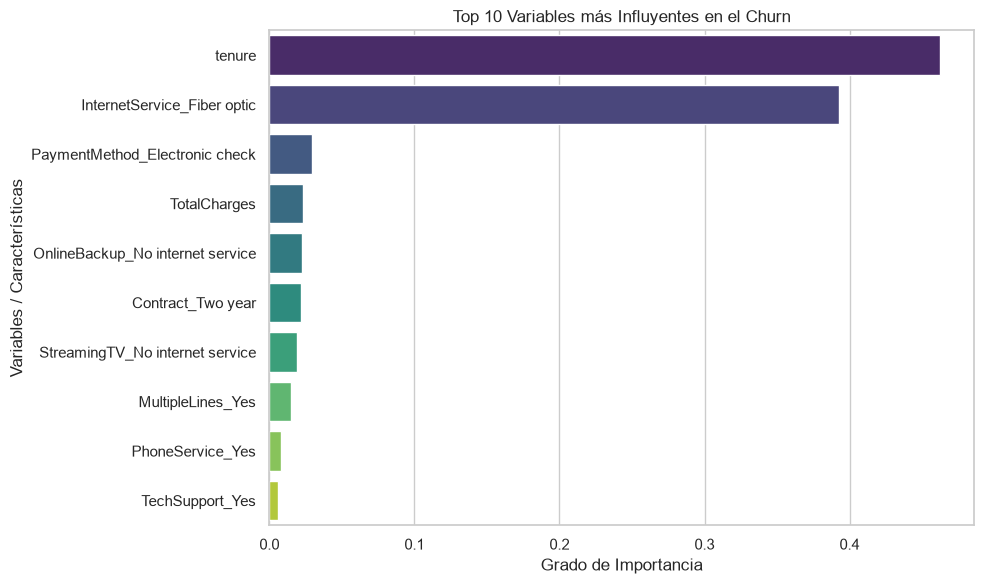

In [13]:
import numpy as np

# 1. Extraer la importancia de las variables del modelo (con un solo guion bajo al final)
importancias = modelo_arbol.feature_importances_
indices = np.argsort(importancias)[::-1]

# 2. Tomar las 10 variables más importantes para que el gráfico no se sature
top_k = 10
top_indices = indices[:top_k]

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias[top_indices], y=X.columns[top_indices], palette='viridis')
plt.title('Top 10 Variables más Influyentes en el Churn')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variables / Características')
plt.tight_layout()
plt.show()